In [11]:
# Step 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
# Step 2: Create Dataset

data = {
    "Annual_Income": [15, 16, 17, 18, 20, 22, 25, 50, 52, 55, 57, 60, 62, 65, 70],
    "Spending_Score": [20, 22, 25, 28, 30, 35, 40, 70, 72, 75, 78, 80, 82, 85, 90]
}

df = pd.DataFrame(data)

print(df)

    Annual_Income  Spending_Score
0              15              20
1              16              22
2              17              25
3              18              28
4              20              30
5              22              35
6              25              40
7              50              70
8              52              72
9              55              75
10             57              78
11             60              80
12             62              82
13             65              85
14             70              90


In [13]:
# Step 3: Select Features

X = df[["Annual_Income", "Spending_Score"]]

print(X.head())

   Annual_Income  Spending_Score
0             15              20
1             16              22
2             17              25
3             18              28
4             20              30


In [14]:
# Step 4: Scale the Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.23006573 -1.36600786]
 [-1.18138239 -1.28897734]
 [-1.13269905 -1.17343157]
 [-1.08401571 -1.05788579]
 [-0.98664903 -0.98085527]]


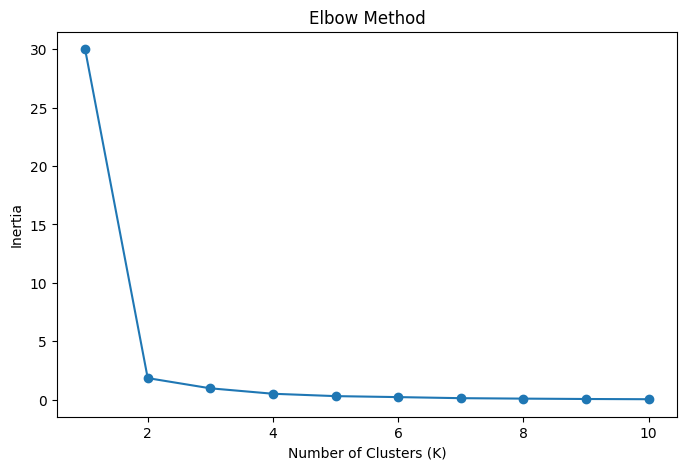

In [15]:
# Step 5: Find the Optimal Number of Clusters using Elbow Method

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [16]:
# Step 6: Apply K-Means

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df)

    Annual_Income  Spending_Score  Cluster
0              15              20        1
1              16              22        1
2              17              25        1
3              18              28        1
4              20              30        1
5              22              35        1
6              25              40        1
7              50              70        2
8              52              72        2
9              55              75        2
10             57              78        2
11             60              80        0
12             62              82        0
13             65              85        0
14             70              90        0


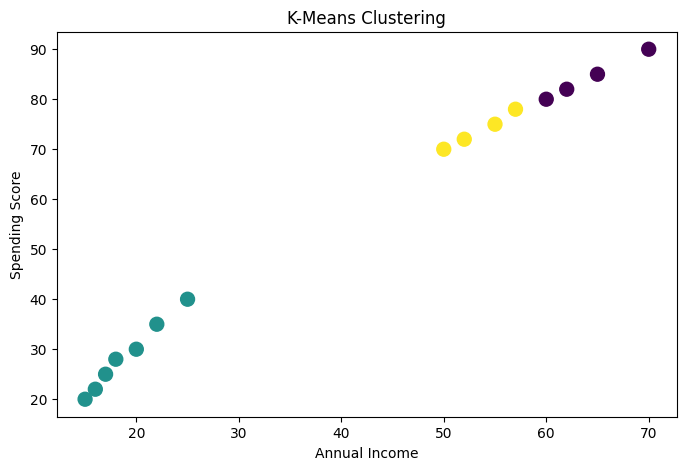

In [17]:
# Step 7: Visualize the Clusters

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

In [18]:
# Step 8: Display Cluster Centers

centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)

print("Cluster Centers:")

for i, center in enumerate(centers):
    print(
        f"Cluster {i}: "
        f"Annual Income = {center[0]:.2f}, "
        f"Spending Score = {center[1]:.2f}"
    )

Cluster Centers:
Cluster 0: Annual Income = 64.25, Spending Score = 84.25
Cluster 1: Annual Income = 19.00, Spending Score = 28.57
Cluster 2: Annual Income = 53.50, Spending Score = 73.75
